# Featurewise Ridge Quality Scoring

This notebook trains a Ridge Regression model that scores candidate Gaussian Splatting training settings from project descriptors.

The model does not directly predict multipliers. Instead, it predicts the relative quality score for many candidate multiplier combinations. The candidate with the highest predicted score is selected, and its multipliers are expanded into final Gaussian Splatting training parameter values.

The notebook is written as a short report. Working sections build the model and predictions. Visualization sections explain the data and the selected values.

## About Bimba3D-re

[Bimba3D-re](https://github.com/geomatupen/bimba3d_re) is an open-source local platform for experimenting with AI-guided 3D Gaussian Splatting workflows. It can be run on a laptop or workstation, and it helps prepare projects, run baseline and exploration Gaussian Splatting training, build training-data folders, train scoring models, upload externally trained scoring models, and run reconstruction tests for selected settings on new drone-based projects.

This notebook includes a prepared training-data folder inside `notebooks/data/`, so it can run without reading from the application folders. The reference data used to run these notebooks is also available on GitHub: [reference training-data folder](https://github.com/geomatupen/bimba3d_re/tree/main/notebooks/data/training_data_20260710_183008_final_offline_data_june_27-training-data). If you prepare a newer dataset in Bimba3D-re, open the **Training Data** tab, build or rebuild the dataset, and copy the resulting folder that contains `manifest.json` and `rows.json` into `notebooks/data/`. Then update `TRAINING_DATA_DIR` in the configuration cell.

For reference, when this data is prepared inside Bimba3D-re, the same files are stored in the application under `bimba3d_backend/data/workflow/training_data/<training_data_id>/`. For the bundled reference dataset, the platform folder name is `bimba3d_backend/data/workflow/training_data/training_data_20260710_183008_final_offline_data_june_27-training-data/`. The notebook still reads from the local `notebooks/data/` copy by default.

After this notebook trains the scoring model, the trained scoring model can also be registered back in Bimba3D-re. Open **Train Models**, click **Upload Model**, select the same Training Data source used here, and upload the saved `compact_featurewise_ridge_model.json`. Once uploaded, the model appears in the model list and can be selected in a testing pipeline.

**Purpose of this notebook:** this notebook explains, trains, and inspects the scoring model outside the application. It saves preview predictions so the selected multiplier values can be reviewed. These preview predictions are not the same as a reconstruction test. For real Gaussian Splatting testing, upload or train the scoring model in the application and evaluate the selected multipliers through a testing workflow.


## 0. Install Notebook Dependencies

Run this cell once if you are using a new Python environment. It installs the packages needed to run the notebook, draw charts, show progress bars, and connect the environment as a notebook kernel.

After the install finishes, the notebook program may ask you to restart the kernel. That is normal. Restart the kernel if asked, then continue with the configuration section.


In [160]:
# Install the packages needed to run this notebook from a fresh Python environment.
# ipykernel and IPython let a notebook application use this Python environment as a kernel.
# numpy does the model math; pandas handles tables; matplotlib draws charts; tqdm shows progress.
%pip install --upgrade ipykernel ipython numpy pandas matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


## 1. Configuration

This section sets the prepared training-data folder used by the notebook. The path is written directly in the configuration cell below. The notebook reads only that folder; it does not search other locations.

The folder must contain two files:

- `manifest.json`: the summary file for the prepared data. It stores details such as descriptor names, multiplier bounds, base parameter values, score name, and hard-cap information when it is present.
- `rows.json`: the table of rows used to train the scoring model.

A reference prepared dataset is included with this notebook under the path below. The same reference data can also be viewed on GitHub: [reference training-data folder](https://github.com/geomatupen/bimba3d_re/tree/main/notebooks/data/training_data_20260710_183008_final_offline_data_june_27-training-data).

`notebooks/data/training_data_20260710_183008_final_offline_data_june_27-training-data/`

This keeps the notebook independent from the application folders. To use a different prepared dataset, copy its folder into `notebooks/data/` and update `TRAINING_DATA_DIR` in the next code cell.

For reference, when this data is prepared inside Bimba3D-re, the same files are stored in the application under `bimba3d_backend/data/workflow/training_data/<training_data_id>/`. For the bundled reference dataset, the platform folder name is `bimba3d_backend/data/workflow/training_data/training_data_20260710_183008_final_offline_data_june_27-training-data/`. The notebook still reads from the local `notebooks/data/` copy by default.

The scoring model learns from `relative_quality_score`. This score describes how good a Gaussian Splatting run was compared with its baseline run. Higher values mean better quality. `CANDIDATE_POINTS` controls how many possible multiplier values are scored during prediction. More points give a finer search, but also make prediction slower.


In [161]:
from __future__ import annotations

import itertools
import json
import math
import os
import shutil
import time
from pathlib import Path
from typing import Any

import numpy as np
from tqdm.auto import tqdm
import pandas as pd

# Keep Matplotlib font and cache files beside the notebook.
# This avoids old font caches elsewhere on the computer from breaking chart cells.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "_matplotlib_cache"))
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker

_dejavu = Path(plt.matplotlib.get_data_path()) / "fonts" / "ttf" / "DejaVuSans.ttf"
if _dejavu.exists():
    font_manager.fontManager.addfont(str(_dejavu))
plt.rcParams["font.family"] = "DejaVu Sans"

try:
    from IPython.display import display
except Exception:
    display = print

NOTEBOOK_WORKING_DIR = Path.cwd()
NOTEBOOK_DIR = NOTEBOOK_WORKING_DIR if NOTEBOOK_WORKING_DIR.name == "notebooks" else NOTEBOOK_WORKING_DIR / "notebooks"
if not NOTEBOOK_DIR.exists():
    # Fallback for unusual notebook launch locations: keep outputs beside the notebook process.
    NOTEBOOK_DIR = NOTEBOOK_WORKING_DIR
NOTEBOOK_ROOT = NOTEBOOK_DIR
OUT_DIR = NOTEBOOK_DIR / "_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# When True, generated notebook outputs reuse fixed paths instead of creating
# new timestamped folders/files on every run.
REPLACE_OUTPUTS = True


def prepare_output_directory(path: Path, *, replace: bool) -> Path:
    """Optionally clear a generated-output directory before writing fresh files."""
    if replace and path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


# Set this to the prepared training-data folder that contains manifest.json and rows.json.
# The default points to the reference dataset bundled with this notebook.
TRAINING_DATA_DIR = str(NOTEBOOK_DIR / "data" / "training_data_20260710_183008_final_offline_data_june_27-training-data")

# This is the target score the model learns to predict.
SCORE_KEY = "relative_quality_score"

# Stored fallback for prediction: if no explicit candidate grid is provided during later use,
# the model checks this many multiplier values inside each group.
CANDIDATE_POINTS = 30

# Ridge lambda controls regularization strength. These candidates are tested to choose the regularization strength.
RIDGE_LAMBDAS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]


print(f"Notebook root:       {NOTEBOOK_ROOT}")
print(f"Training data dir:   {TRAINING_DATA_DIR}")
print(f"Notebook output dir: {OUT_DIR}")
print(f"Replace outputs:     {REPLACE_OUTPUTS}")

RUN_LABEL = time.strftime("%Y%m%d_%H%M%S")
MODEL_SLUG = "compact_ridge"
CHART_DIR = prepare_output_directory(
    OUT_DIR / "charts" / (MODEL_SLUG if REPLACE_OUTPUTS else f"{MODEL_SLUG}_{RUN_LABEL}"),
    replace=REPLACE_OUTPUTS,
)

CHART_COLORS = {
    "blue": "#2563eb",
    "green": "#16a34a",
    "orange": "#f97316",
    "slate": "#64748b",
    "slate_axis": "#94a3b8",
    "grid": "#e2e8f0",
    "panel": "#f8fafc",
    "border": "#cbd5e1",
}

GROUP_DISPLAY = {
    "geometry_lr_mult": "Geometry",
    "appearance_lr_mult": "Appearance",
    "densification_mult": "Densification",
}

GROUP_COLORS = {
    "geometry_lr_mult": CHART_COLORS["blue"],
    "appearance_lr_mult": CHART_COLORS["green"],
    "densification_mult": CHART_COLORS["orange"],
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": CHART_COLORS["panel"],
    "axes.edgecolor": CHART_COLORS["slate_axis"],
    "axes.labelcolor": "#334155",
    "axes.titlecolor": "#0f172a",
    "xtick.color": CHART_COLORS["slate"],
    "ytick.color": CHART_COLORS["slate"],
    "grid.color": CHART_COLORS["grid"],
    "grid.linewidth": 0.8,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": CHART_COLORS["border"],
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
})


def safe_filename(value: Any, max_len: int = 70) -> str:
    """Make a short file-safe name for chart and output files."""
    text = str(value or "chart").strip().replace(" ", "_")
    safe = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in text)
    safe = "_".join(part for part in safe.split("_") if part)
    return (safe or "chart")[:max_len]


def style_chart_axis(ax, *, title: str | None = None, xlabel: str | None = None, ylabel: str | None = None, grid: bool = True):
    """Apply one consistent chart style so all plots read like one report."""
    ax.set_facecolor(CHART_COLORS["panel"])
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(CHART_COLORS["slate_axis"])
    ax.spines["bottom"].set_color(CHART_COLORS["slate_axis"])
    ax.tick_params(colors=CHART_COLORS["slate"], labelsize=9)
    if grid:
        ax.grid(True, color=CHART_COLORS["grid"], linewidth=0.8, alpha=1.0)
        ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=11, fontweight="semibold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, color="#334155")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, color="#334155")
    return ax


def add_score_zero_line(ax, *, label: str = "score = 0"):
    """Draw the zero-score reference line when it falls inside the visible y-range."""
    ymin, ymax = ax.get_ylim()
    if ymin <= 0 <= ymax:
        ax.axhline(0, color=CHART_COLORS["orange"], linestyle=(0, (4, 3)), linewidth=1.5, label=label, zorder=1)


def add_multiplier_reference_line(ax, *, label: str = "multiplier = 1.0"):
    """Draw the multiplier 1.0 reference line, which means no parameter change."""
    ax.axhline(1.0, color=CHART_COLORS["orange"], linestyle=(0, (4, 3)), linewidth=1.5, label=label, zorder=1)


def set_multiplier_log_y_axis(ax, values: Any | None = None):
    """Space multiplier values evenly by ratio while labeling ticks with the real values."""
    ticks = [1.0]
    positive_values: list[float] = []
    bounds = globals().get("GROUP_BOUNDS", {})
    if isinstance(bounds, dict):
        for bound_pair in bounds.values():
            if isinstance(bound_pair, (list, tuple)) and len(bound_pair) == 2:
                ticks.extend([float(bound_pair[0]), float(bound_pair[1])])
    if values is not None:
        for value in np.asarray(list(values), dtype=float).ravel():
            if math.isfinite(float(value)) and float(value) > 0:
                positive_values.append(float(value))
    # Keep the axis readable: show the search bounds and the no-change line,
    # while the plotted bars/points carry exact selected values where needed.
    if positive_values:
        ticks.extend([min(positive_values), max(positive_values)])
    clean_ticks = sorted({round(float(value), 10) for value in ticks if float(value) > 0})
    if len(clean_ticks) > 9:
        # Thin labels only when the axis becomes crowded; keep the no-change label visible.
        clean_ticks = [value for idx, value in enumerate(clean_ticks) if idx % 2 == 0]
        if 1.0 not in clean_ticks:
            clean_ticks.append(1.0)
            clean_ticks = sorted(clean_ticks)
    tick_labels = {round(float(value), 10): compact_number(value, 3) for value in clean_ticks}
    ax.set_yscale("log")
    ax.set_yticks(clean_ticks)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda value, _pos: tick_labels.get(round(float(value), 10), ""))
    )
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())


def set_multiplier_log_x_axis(ax, values: Any | None = None, bounds: tuple[float, float] | None = None):
    """Use log spacing on multiplier x-axes while showing decimal multiplier labels."""
    positive_values: list[float] = []
    if values is not None:
        for value in np.asarray(list(values), dtype=float).ravel():
            if math.isfinite(float(value)) and float(value) > 0:
                positive_values.append(float(value))

    if isinstance(bounds, (list, tuple)) and len(bounds) == 2:
        tick_lo, tick_hi = float(bounds[0]), float(bounds[1])
    elif positive_values:
        tick_lo, tick_hi = min(positive_values), max(positive_values)
    else:
        tick_lo, tick_hi = 0.5, 2.0

    axis_lo, axis_hi = tick_lo, tick_hi
    if positive_values:
        axis_lo = min(axis_lo, min(positive_values))
        axis_hi = max(axis_hi, max(positive_values))

    if tick_lo <= 0 or tick_hi <= tick_lo:
        tick_lo, tick_hi = axis_lo, axis_hi
    if axis_lo <= 0 or axis_hi <= axis_lo:
        axis_lo, axis_hi = tick_lo, tick_hi

    # Use clean per-group ticks. Observed min/max set the visible range, but they are
    # not added as labels because values close to the bounds create crowded pairs.
    if tick_lo < 1.0 < tick_hi:
        if tick_hi / tick_lo > 2.5:
            tick_values = [tick_lo, math.sqrt(tick_lo), 1.0, math.sqrt(tick_hi), tick_hi]
        else:
            tick_values = [tick_lo, 1.0, tick_hi]
    else:
        tick_values = np.geomspace(tick_lo, tick_hi, num=4).tolist()

    clean_ticks = []
    for value in tick_values:
        if value > 0 and axis_lo <= value <= axis_hi:
            rounded = round(float(value), 10)
            if rounded not in clean_ticks:
                clean_ticks.append(rounded)
    tick_labels = {round(float(value), 10): compact_number(value, 3) for value in clean_ticks}

    ax.set_xscale("log")
    pad = math.exp(math.log(axis_hi / axis_lo) * 0.06)
    ax.set_xlim(axis_lo / pad, axis_hi * pad)
    ax.xaxis.set_major_locator(ticker.FixedLocator(clean_ticks))
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda value, _pos: tick_labels.get(round(float(value), 10), ""))
    )
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())


def save_chart(fig, name: str, *, directory: Path | None = None) -> tuple[Path, Path]:
    """Save each chart as PNG for viewing and SVG for clean scaling in documents."""
    target_dir = directory or CHART_DIR
    target_dir.mkdir(parents=True, exist_ok=True)
    base = target_dir / safe_filename(name)
    png_path = base.with_suffix(".png")
    svg_path = base.with_suffix(".svg")
    fig.savefig(png_path, dpi=160)
    fig.savefig(svg_path)
    print(f"Saved chart: {png_path}")
    print(f"Saved chart: {svg_path}")
    return png_path, svg_path


def short_label(value: Any, max_len: int = 18) -> str:
    """Shorten long project names so chart labels stay readable."""
    text = str(value or "")
    return text if len(text) <= max_len else f"{text[: max_len - 3]}..."




def compact_number(value: Any, digits: int = 4) -> str:
    """Format numbers for chart labels without unnecessary trailing zeros."""
    try:
        number = float(value)
    except (TypeError, ValueError):
        return str(value)
    if not math.isfinite(number):
        return str(value)
    if number == 0:
        return "0"
    if abs(number) >= 1000 or abs(number) < 0.001:
        return f"{number:.2e}"
    return f"{number:.{digits}f}".rstrip("0").rstrip(".")


def annotate_point(ax, x: float, y: float, text: str, *, color: str | None = None, xytext: tuple[int, int] = (8, 8)):
    """Add a small label to an important chart point, usually the selected value."""
    ax.annotate(
        text,
        xy=(x, y),
        xytext=xytext,
        textcoords="offset points",
        fontsize=8,
        color=color or "#0f172a",
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": CHART_COLORS["border"], "alpha": 0.92},
        arrowprops={"arrowstyle": "-", "color": color or CHART_COLORS["slate_axis"], "linewidth": 0.8},
    )


def annotate_bars(ax, bars, *, fmt_digits: int = 0, min_height: float = 0):
    """Write numeric values above bars when the chart is not too crowded."""
    for bar in bars:
        height = float(bar.get_height())
        if height <= min_height:
            continue
        ax.annotate(
            compact_number(height, fmt_digits),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#0f172a",
        )


def plot_candidate_curve_set(row: dict[str, Any], *, save_name: str | None = None, show: bool = True, save: bool = True, directory: Path | None = None):
    """Plot candidate-score curves for the three multiplier groups of one project."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
    for ax, group in zip(axes, COMPACT_MODEL_GROUP_KEYS):
        df_curve = pd.DataFrame(row["candidate_score_checks"][group]).sort_values("candidate_multiplier")
        ax.plot(
            df_curve["candidate_multiplier"],
            df_curve["predicted_score"],
            color=CHART_COLORS["blue"],
            marker="o",
            markersize=4,
            linewidth=1.8,
            label="Predicted score",
        )
        selected = df_curve[df_curve["selected"]]
        if not selected.empty:
            sx = float(selected["candidate_multiplier"].iloc[0])
            sy = float(selected["predicted_score"].iloc[0])
            ax.scatter([sx], [sy], color=CHART_COLORS["green"], s=70, zorder=5, label="Selected highest score")
            ax.axvline(sx, color=CHART_COLORS["green"], linestyle=(0, (3, 3)), linewidth=1.2, alpha=0.85)
            annotate_point(ax, sx, sy, f"mult={compact_number(sx)}\nscore={compact_number(sy)}", color=CHART_COLORS["green"])
        ax.set_xscale("log")
        tick_values = sorted(float(v) for v in df_curve["candidate_multiplier"].dropna().unique())
        # Label about half of the candidate ticks so each label sits clearly under its tick.
        # The curve still uses all candidate points; this only reduces axis label crowding.
        label_tick_values = tick_values[::3]
        if tick_values and tick_values[-1] not in label_tick_values:
            label_tick_values.append(tick_values[-1])
        ax.set_xticks(label_tick_values)
        ax.set_xticklabels([compact_number(v, 3) for v in label_tick_values], rotation=0, ha="center", fontsize=8)
        ax.minorticks_off()
        style_chart_axis(
            ax,
            title=GROUP_DISPLAY.get(group, group),
            xlabel="Candidate multiplier (log scale; labels show actual values)",
            ylabel="Predicted score",
        )
        add_score_zero_line(ax, label="score = 0")
        ax.legend(loc="best", fontsize=8)
    fig.suptitle(f"Candidate multiplier curves: {row['project_name']}", fontsize=13, fontweight="semibold")
    if save:
        save_chart(fig, save_name or f"candidate_curves_{row['project_name']}", directory=directory)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

print(f"Chart output dir:    {CHART_DIR}")

Notebook root:       D:\bimba3d-re\notebooks
Training data dir:   D:\bimba3d-re\notebooks\data\training_data_20260710_183008_final_offline_data_june_27-training-data
Notebook output dir: D:\bimba3d-re\notebooks\_outputs
Replace outputs:     True
Chart output dir:    D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge


In [ ]:
# Keep all Ridge-generated files inside a notebook-specific output folder.
OUT_DIR = OUT_DIR / MODEL_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR = prepare_output_directory(
    OUT_DIR / ("charts" if REPLACE_OUTPUTS else f"charts_{RUN_LABEL}"),
    replace=REPLACE_OUTPUTS,
)
print(f"Notebook-specific output dir: {OUT_DIR}")
print(f"Chart output dir:             {CHART_DIR}")

## 2. Descriptors And Scoring Structure

This section defines the exact inputs and outputs used by the model.

Here, **compact** has a specific meaning. The model uses a smaller number of descriptors, and it scores the three multiplier groups together with one shared model. Earlier, a three-model structure was also tested, where geometry, appearance, and densification each had their own separate model. That separate structure was useful to try because the available training data is limited, and smaller individual models can reduce the number of learned parameters. However, the three multiplier groups may not be fully independent. A geometry choice can change how appearance learning behaves, and densification can affect both geometry and appearance. Because of this, scoring only one group at a time can miss how the full setting works together. This notebook therefore uses the shared candidate-scoring structure: it scores complete geometry, appearance, and densification combinations together, then selects the combination with the highest predicted relative quality score. In later Gaussian Splatting reconstruction tests, this shared structure gave better results, so it is used here as the final model structure.

A **descriptor** is one measured property of a project. Examples are image scale, image overlap, texture amount, blur risk, terrain roughness, and vegetation cover. The compact descriptor list keeps the input table smaller and easier to inspect.

A **multiplier** changes a Gaussian Splatting training parameter by multiplication. A multiplier of `1.0` means no change. A multiplier of `2.0` doubles the base value. A multiplier of `0.5` halves it.

The model scores three multiplier groups:

- **Geometry**: parameters that mainly affect geometric learning.
- **Appearance**: parameters that mainly affect color and appearance learning.
- **Densification**: parameters that affect how new Gaussians are added or removed.

One shared scoring model scores the full candidate combination, instead of using three separate models to score geometry, appearance, and densification independently. The notebook later expands the selected group multipliers into final Gaussian Splatting parameter values. `gsd_median` is log-transformed because scale values behave multiplicatively: moving from `0.02` to `0.04` is similar to moving from `0.10` to `0.20`.


In [162]:
# These are the three multiplier groups scored by the model.
# Each group controls several final Gaussian Splatting training parameters together.
# The model scores candidate group multipliers first; the selected candidates are expanded into final Gaussian Splatting parameter values.
COMPACT_MODEL_GROUP_KEYS = ["geometry_lr_mult", "appearance_lr_mult", "densification_mult"]

# The compact model uses the smaller descriptor list below.
# "intercept" is not read from data. It gives the model a constant baseline term.
COMPACT_FEATURE_KEYS = [
    "intercept",
    "gsd_median",
    "overlap_proxy",
    "coverage_spread",
    "camera_angle_bucket",
    "heading_consistency",
    "texture_density",
    "blur_motion_risk",
    "terrain_roughness_proxy",
    "vegetation_complexity_score",
    "vegetation_cover_percentage",
]

# GSD behaves multiplicatively: 0.02 to 0.04 is a similar scale change as 0.10 to 0.20.
# A log transform lets the model see those scale changes more evenly.
COMPACT_LOG_TRANSFORM_FEATURES = {"gsd_median"}
COMPACT_SCALER_STD_FLOOR = 0.01

COMPACT_GROUP_BOUNDS = {
    "geometry_lr_mult": (0.5, 2.0),
    "appearance_lr_mult": (0.5, 2.0),
    "densification_mult": (0.7, 1.4285714286),
}

# Prepared training-data manifests may store multiplier bounds with short group names
# such as geometry_lr, appearance_lr, or scale_lr. The notebook maps those names to
# the three group keys used in the training rows and prediction tables below.
COMPACT_GROUP_BOUND_ALIASES = {
    "geometry_lr": "geometry_lr_mult",
    "geometry": "geometry_lr_mult",
    "appearance_lr": "appearance_lr_mult",
    "appearance": "appearance_lr_mult",
    "scale_lr": "densification_mult",
    "densification": "densification_mult",
    "densification_lr": "densification_mult",
}

COMPACT_PARAMETER_GROUPS = {
    "geometry_lr_mult": ["position_lr_init_mult", "scaling_lr_mult", "rotation_lr_mult"],
    "appearance_lr_mult": ["feature_lr_mult", "opacity_lr_mult", "lambda_dssim_mult"],
    "densification_mult": ["densify_grad_threshold_mult", "opacity_threshold_mult"],
}


def clamp_float(value: float, lo: float, hi: float) -> float:
    """Keep a numeric value inside an allowed lower and upper bound."""
    return max(lo, min(hi, float(value)))


def normalise_compact_group_bounds(bounds: dict[str, Any] | None = None) -> dict[str, tuple[float, float]]:
    """Return clean positive bounds for the compact multiplier search."""
    out = dict(COMPACT_GROUP_BOUNDS)
    if not isinstance(bounds, dict):
        return out
    for raw_key, raw_value in bounds.items():
        group_key = COMPACT_GROUP_BOUND_ALIASES.get(str(raw_key), str(raw_key))
        if group_key not in out or not isinstance(raw_value, (list, tuple)) or len(raw_value) < 2:
            continue
        try:
            lo = float(raw_value[0])
            hi = float(raw_value[1])
        except (TypeError, ValueError):
            continue
        if not math.isfinite(lo) or not math.isfinite(hi) or lo <= 0.0 or hi <= 0.0:
            continue
        if hi < lo:
            lo, hi = hi, lo
        out[group_key] = (lo, hi)
    return out


def _feature_float(features: dict[str, Any], key: str, default: float, *, positive: bool = False) -> float:
    """Read one numeric descriptor safely and fall back to a simple default when needed."""
    value = features.get(key)
    if isinstance(value, bool):
        return default
    if isinstance(value, (int, float)):
        parsed = float(value)
        if math.isfinite(parsed) and (parsed > 0.0 if positive else True):
            return parsed
    return default


def compact_raw_feature(features: dict[str, Any], name: str) -> float:
    """Read one descriptor with built-in defaults for incomplete rows."""
    if name == "gsd_median":
        return _feature_float(features, "gsd_median", 0.05, positive=True)
    if name == "overlap_proxy":
        return _feature_float(features, "overlap_proxy", 0.5)
    if name == "coverage_spread":
        return _feature_float(features, "coverage_spread", 0.5)
    if name == "camera_angle_bucket":
        return _feature_float(features, "camera_angle_bucket", 0.0)
    if name == "heading_consistency":
        return _feature_float(features, "heading_consistency", 0.5)
    if name == "texture_density":
        return _feature_float(features, "texture_density", 0.5)
    if name == "blur_motion_risk":
        return _feature_float(features, "blur_motion_risk", 0.5)
    if name == "terrain_roughness_proxy":
        if "terrain_roughness_proxy" in features:
            return _feature_float(features, "terrain_roughness_proxy", 0.5)
        return _feature_float(features, "terrain_roughness", 0.5)
    if name == "vegetation_complexity_score":
        if "vegetation_complexity_score" in features:
            return _feature_float(features, "vegetation_complexity_score", 0.5)
        return _feature_float(features, "vegetation_complexity", 0.5)
    if name == "vegetation_cover_percentage":
        if "vegetation_cover_percentage" in features:
            return _feature_float(features, "vegetation_cover_percentage", 0.5)
        return _feature_float(features, "vegetation_cover", 0.5)
    return 0.0


def compact_transform_feature(name: str, value: float) -> float:
    """Apply descriptor transforms before the value is used by the model."""
    return math.log(max(float(value), 1e-9)) if name in COMPACT_LOG_TRANSFORM_FEATURES else float(value)


def build_compact_feature_scaler(rows: list[dict[str, Any]]) -> dict[str, dict[str, float]]:
    """Fit the Ridge scaler from training rows.

    Ridge solves a linear system, so very different feature scales can dominate the solution.
    For that reason, this notebook scales descriptors before fitting the linear model.
    """
    values_by_feature = {name: [] for name in COMPACT_FEATURE_KEYS if name != "intercept"}
    for row in rows:
        features = row.get("x_features")
        if not isinstance(features, dict) or not features:
            continue
        for name in values_by_feature:
            values_by_feature[name].append(compact_transform_feature(name, compact_raw_feature(features, name)))
    scaler = {}
    for name, values in values_by_feature.items():
        if not values:
            scaler[name] = {"mean": 0.0, "std": 1.0}
        else:
            arr = np.array(values, dtype=np.float64)
            scaler[name] = {"mean": float(np.mean(arr)), "std": max(float(np.std(arr)), COMPACT_SCALER_STD_FLOOR)}
    return scaler


def build_compact_vector(features: dict[str, Any], scaler: dict[str, dict[str, float]] | None = None) -> np.ndarray:
    """Build the compact context vector used by both compact models."""
    values = []
    scaler = scaler or {}
    for name in COMPACT_FEATURE_KEYS:
        if name == "intercept":
            values.append(1.0)
            continue
        transformed = compact_transform_feature(name, compact_raw_feature(features, name))
        stats = scaler.get(name)
        if isinstance(stats, dict):
            std = max(float(stats.get("std", 1.0)), COMPACT_SCALER_STD_FLOOR)
            values.append((transformed - float(stats.get("mean", 0.0))) / std)
        else:
            values.append(transformed)
    return np.array(values, dtype=np.float64)


def compact_action_logs_from_multipliers(multipliers: dict[str, Any], bounds: dict[str, tuple[float, float]] | None = None) -> np.ndarray | None:
    """Convert stored parameter multipliers into the three compact log actions."""
    bounds = normalise_compact_group_bounds(bounds)
    logs = []
    for group_key in COMPACT_MODEL_GROUP_KEYS:
        direct = multipliers.get(group_key)
        value = float(direct) if isinstance(direct, (int, float)) and not isinstance(direct, bool) and float(direct) > 0 else None
        if value is None:
            # Some rows may store per-parameter multipliers instead of compact group multipliers.
            # Group members are averaged so the compact model can still use that row.
            members = [
                float(multipliers[key])
                for key in COMPACT_PARAMETER_GROUPS[group_key]
                if isinstance(multipliers.get(key), (int, float)) and not isinstance(multipliers.get(key), bool) and float(multipliers[key]) > 0
            ]
            value = float(np.mean(members)) if members else None
        if value is None:
            return None
        lo, hi = bounds[group_key]
        logs.append(float(math.log(max(clamp_float(value, lo, hi), 1e-9))))
    return np.array(logs, dtype=np.float64)


def build_compact_score_design_vector(x_context: np.ndarray, action_logs: np.ndarray) -> np.ndarray:
    """Score features: context, action values, action curvature, and context-action interactions."""
    x = np.asarray(x_context, dtype=np.float64)
    a = np.asarray(action_logs, dtype=np.float64)
    interactions = np.concatenate([x[1:] * float(value) for value in a], axis=0)
    return np.concatenate([x, a, a * a, interactions], axis=0)


def expand_compact_group_multipliers(group_multipliers: dict[str, float]) -> tuple[dict[str, float], dict[str, float]]:
    """Expand three compact group choices into the final parameter multipliers used by training."""
    multipliers = {}
    log_multipliers = {}
    for group_key, member_keys in COMPACT_PARAMETER_GROUPS.items():
        group_mult = float(group_multipliers[group_key])
        group_log = float(math.log(max(group_mult, 1e-9)))
        for member_key in member_keys:
            multipliers[member_key] = group_mult
            log_multipliers[member_key] = group_log
    return multipliers, log_multipliers


print("Compact descriptors:")
display(pd.DataFrame({"descriptor": [key for key in COMPACT_FEATURE_KEYS if key != "intercept"]}))


Compact descriptors:


,descriptor
0,gsd_median
1,overlap_proxy
2,coverage_spread
3,camera_angle_bucket
4,heading_consistency
5,texture_density
6,blur_motion_risk
7,terrain_roughness_proxy
8,vegetation_complexity_score
9,vegetation_cover_percentage


## 3. Load Training Data

This section reads the prepared training-data folder and checks that the files contain the information needed for a complete run.

The notebook expects `manifest.json` to contain the saved training-data summary: descriptor names, multiplier bounds, base parameter values, score name, and hard-cap information when it is present. **Base parameters** are the original Gaussian Splatting training parameter values before multipliers are applied. Keeping them inside the training-data folder makes the notebook self-contained: final values are always computed from the same snapshot that produced the training rows.


In [163]:
def load_json(path: Path) -> Any:
    """Read one JSON file from the selected training-data folder."""
    return json.loads(path.read_text(encoding="utf-8"))


def selected_training_data_folder() -> Path:
    """Validate the exact training-data folder selected in the configuration cell."""
    folder = Path(TRAINING_DATA_DIR).expanduser()
    if not folder.exists():
        raise FileNotFoundError(f"TRAINING_DATA_DIR does not exist: {folder}")
    manifest_path = folder / "manifest.json"
    rows_path = folder / "rows.json"
    missing = [str(path) for path in (manifest_path, rows_path) if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "The selected training-data folder must contain manifest.json and rows.json. "
            f"Missing: {missing}"
        )
    return folder


def first_dict(*values: Any) -> dict[str, Any]:
    """Return the first non-empty dictionary from several possible row fields."""
    for value in values:
        if isinstance(value, dict) and value:
            return dict(value)
    return {}


def first_number(source: dict[str, Any], keys: tuple[str, ...]) -> float | None:
    """Return the first usable numeric score from several possible score fields."""
    for key in keys:
        value = source.get(key)
        if isinstance(value, bool):
            continue
        if isinstance(value, (int, float)) and math.isfinite(float(value)):
            return float(value)
    return None


def clean_features(features: Any) -> dict[str, Any]:
    """Return the descriptor fields used by the notebook."""
    if not isinstance(features, dict):
        return {}
    return {key: value for key, value in features.items() if not str(key).lower().endswith("_missing")}


def normalise_training_row(row: dict[str, Any], source_path: Path) -> dict[str, Any] | None:
    """Convert one raw row into the simple row shape used by the notebook."""
    # Baseline rows are reference runs. The scoring model learns from non-baseline runs
    # where a candidate setting was tried and received a relative quality score.
    if row.get("is_baseline_row"):
        return None
    features = clean_features(first_dict(row.get("x_features"), row.get("features"), row.get("project_features"), row.get("descriptors")))
    selected = first_dict(row.get("selected_multipliers"), row.get("multipliers"), row.get("y_multipliers"))
    score = first_number(row, (SCORE_KEY, "score", "quality_delta", "relative_score"))
    # A usable training row needs descriptors, selected multipliers, and a target score.
    if not features or not selected or score is None:
        return None
    return {
        "project_id": row.get("project_id") or row.get("id") or source_path.stem,
        "project_name": row.get("project_name") or row.get("name") or source_path.stem,
        "run_id": row.get("run_id"),
        "phase": row.get("phase"),
        "x_features": features,
        "features": features,
        "selected_multipliers": selected,
        "selected_log_multipliers": row.get("selected_log_multipliers") or {},
        "metadata": row.get("metadata") or {},
        SCORE_KEY: score,
        "source_path": str(source_path),
    }


def bounds_from_training_data_manifest(manifest: dict[str, Any]) -> tuple[dict[str, tuple[float, float]], str]:
    """Read multiplier bounds from manifest.json, the prepared-data summary file."""
    build_summary = manifest.get("build_summary") if isinstance(manifest.get("build_summary"), dict) else {}
    raw_bounds = build_summary.get("log_multiplier_bounds")
    if not isinstance(raw_bounds, dict) or not raw_bounds:
        raise ValueError(
            "This Training-data folder does not contain log_multiplier_bounds. "
            "Prepare the dataset again so the training-data folder stores its training snapshot."
        )
    # Bounds may use short names in manifest.json; normalize them before checking completeness.
    present_groups = {COMPACT_GROUP_BOUND_ALIASES.get(str(key), str(key)) for key in raw_bounds}
    missing = [group for group in COMPACT_MODEL_GROUP_KEYS if group not in present_groups]
    if missing:
        raise ValueError(f"Training-data folder is missing compact multiplier bounds for: {missing}")
    source = str(build_summary.get("log_multiplier_bounds_source") or "training_data_manifest")
    return normalise_compact_group_bounds(raw_bounds), source


def base_params_from_training_data_manifest(manifest: dict[str, Any]) -> tuple[dict[str, float], str]:
    """Read base parameter values from manifest.json so final values match the data snapshot."""
    build_summary = manifest.get("build_summary") if isinstance(manifest.get("build_summary"), dict) else {}
    snapshot = build_summary.get("training_data_config_snapshot") if isinstance(build_summary.get("training_data_config_snapshot"), dict) else {}
    # Base parameters are the original values before multipliers are applied.
    raw_params = build_summary.get("base_params") if isinstance(build_summary.get("base_params"), dict) else snapshot.get("base_params")
    if not isinstance(raw_params, dict) or not raw_params:
        raise ValueError(
            "This Training-data folder does not contain base_params. "
            "Prepare the dataset again so final Gaussian Splatting parameter values come from the training-data folder, not notebook defaults."
        )
    required = [
        "feature_lr",
        "position_lr_init",
        "scaling_lr",
        "opacity_lr",
        "rotation_lr",
        "densify_grad_threshold",
        "opacity_threshold",
        "lambda_dssim",
    ]
    out: dict[str, float] = {}
    missing: list[str] = []
    for key in required:
        value = raw_params.get(key)
        if isinstance(value, bool) or not isinstance(value, (int, float)) or not math.isfinite(float(value)):
            missing.append(key)
        else:
            out[key] = float(value)
    if missing:
        raise ValueError(f"Training-data folder is missing numeric base_params for: {missing}")
    source = str(build_summary.get("base_params_source") or snapshot.get("base_params_source") or "training_data_manifest")
    return out, source


training_data_dir = selected_training_data_folder()
manifest = load_json(training_data_dir / "manifest.json")
raw_rows = load_json(training_data_dir / "rows.json")
training_rows = [row for raw in raw_rows if isinstance(raw, dict) for row in [normalise_training_row(raw, training_data_dir / "rows.json")] if row]

# Prediction preview uses rows from the prepared training data so no extra configuration file is needed.
test_projects = []
seen_projects = set()
for row in training_rows:
    if row["project_id"] in seen_projects:
        continue
    test_projects.append({"project_id": row["project_id"], "project_name": row["project_name"], "features": row["features"], "source_path": row["source_path"]})
    seen_projects.add(row["project_id"])

GROUP_BOUNDS, GROUP_BOUNDS_SOURCE = bounds_from_training_data_manifest(manifest)
# Base parameters come from the prepared training data so final values stay tied to this dataset snapshot.
BASE_PARAMS, BASE_PARAMS_SOURCE = base_params_from_training_data_manifest(manifest)
build_summary = manifest.get("build_summary") or {}
print("Training-data folder")
print("----------------------")
print(f"folder:              {training_data_dir}")
print(f"id:                  {manifest.get('training_data_id')}")
print(f"name:                {manifest.get('name')}")
print(f"rows in folder:    {len(raw_rows)}")
print(f"training rows used:  {len(training_rows)}")
print(f"source data id:      {manifest.get('source_pipeline_id')}")
print(f"score key:           {build_summary.get('score_key', SCORE_KEY)}")
print(f"hard-cap rows:       {build_summary.get('hard_cap_penalty_rows', 0)}")
print(f"hard-cap penalty:    {build_summary.get('hard_cap_penalty')}")
print(f"gaussian hard cap:   {build_summary.get('gaussian_hard_cap')}")
print(f"multiplier bounds:   {GROUP_BOUNDS_SOURCE} -> {GROUP_BOUNDS}")
print(f"base params:         {BASE_PARAMS_SOURCE} -> {BASE_PARAMS}")

if training_rows:
    display(pd.DataFrame([{"project": r["project_name"], "run_id": r.get("run_id"), "score": r[SCORE_KEY], "hard_cap": bool(r.get("metadata", {}).get("is_hard_cap_penalty_row"))} for r in training_rows[:12]]))
else:
    raise ValueError("No valid training rows found in the selected Training-data folder.")


Training-data folder
----------------------
folder:              D:\bimba3d-re\notebooks\data\training_data_20260710_183008_final_offline_data_june_27-training-data
id:                  training_data_20260710_183008_final_offline_data_june_27-training-data
name:                Final_offline_data_June_27 Training Data
rows in folder:    653
training rows used:  653
source data id:      pipeline_55776ebd244e
score key:           relative_quality_score
hard-cap rows:       0
hard-cap penalty:    None
gaussian hard cap:   None
multiplier bounds:   source_pipeline.fixed_log_space_bounds_snapshot -> {'geometry_lr_mult': (0.2, 5.0), 'appearance_lr_mult': (0.2, 5.0), 'densification_mult': (0.7, 1.43)}
base params:         built_in_base_params_snapshot -> {'feature_lr': 0.0025, 'position_lr_init': 0.00016, 'scaling_lr': 0.005, 'opacity_lr': 0.05, 'rotation_lr': 0.001, 'densify_grad_threshold': 0.0002, 'opacity_threshold': 0.005, 'lambda_dssim': 0.2}


,project,run_id,score,hard_cap
0,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run10_20260710_035153,0.017791,False
1,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run11_20260706_205654,0.044199,False
2,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run12_20260707_004251,-0.212381,False
3,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run13_20260707_121531,-0.018172,False
4,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run14_20260708_011209,-0.007883,False
5,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run15_20260708_104004,-0.000125,False
6,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run1_20260708_221316,-0.185065,False
7,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run2_20260702_174506,-0.010570,False
8,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run3_20260709_083747,-0.029192,False
9,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run4_20260703_161832,-0.069004,False


## 4. Inspect Descriptor Data

Before training a model, this section prints the rows that will be used.

The printed tables help answer simple but important questions: How many rows are available? What score range is present? Does this prepared data include hard-cap penalty rows? Do the compact descriptors have reasonable numeric values? What compact group multipliers were selected in the training rows?

If the prepared data contains **hard-cap penalty rows**, those rows came from runs that reached the Gaussian hard cap. They are kept as negative examples because they show settings that led to an undesirable outcome. If the prepared data was built without hard-cap rows, this notebook simply trains without them. Any penalty score is read from the prepared training data; the notebook does not invent or recalculate it.

Some tables are made with pandas `describe()`. These tables summarize a numeric column without printing every row. Read the quartile columns like this:

- `25%` means one quarter of the rows have a value at or below this number. This is also called the first quartile.
- `50%` means half of the rows are below this number and half are above it. This is the median, so it is often better than the mean when a few values are unusually high or low.
- `75%` means three quarters of the rows have a value at or below this number. This is also called the third quartile.

For example, if `gsd_median` has `25% = 0.027`, `50% = 0.050`, and `75% = 0.065`, then most rows sit between about `0.027` and `0.065`, and the middle row is about `0.050`. The `min` and `max` columns show the full range, while the quartiles show where the bulk of the data sits.


In [164]:
if not training_rows:
    print("No descriptor table to display.")
else:
    descriptor_rows = []
    multiplier_rows = []
    for row in training_rows:
        record = {
            "project": row["project_name"],
            "run_id": row.get("run_id"),
            "score": row[SCORE_KEY],
            "hard_cap_penalty_row": bool(row.get("metadata", {}).get("is_hard_cap_penalty_row")),
        }
        for key in COMPACT_FEATURE_KEYS:
            if key != "intercept":
                record[key] = compact_raw_feature(row["features"], key)
        descriptor_rows.append(record)

        # These compact group multipliers are the candidate-setting values the model learns from.
        # If a row stores per-parameter multipliers, they are converted into compact group values.
        logs = compact_action_logs_from_multipliers(row["selected_multipliers"], bounds=GROUP_BOUNDS)
        if logs is not None:
            for group, log_value in zip(COMPACT_MODEL_GROUP_KEYS, logs):
                multiplier_rows.append({
                    "project": row["project_name"],
                    "group": group,
                    "log_multiplier": float(log_value),
                    "multiplier": float(math.exp(float(log_value))),
                    "score": row[SCORE_KEY],
                    "hard_cap_penalty_row": bool(row.get("metadata", {}).get("is_hard_cap_penalty_row")),
                })

    df_descriptors = pd.DataFrame(descriptor_rows)
    df_multipliers = pd.DataFrame(multiplier_rows)

    print("Dataset summary")
    print("score_min, score_mean, and score_max describe the relative quality scores used as the training target.")
    print("hard_cap_penalty_rows counts rows that were added as negative examples because a run reached the Gaussian hard cap.")
    display(pd.DataFrame([{
        "training_rows": len(training_rows),
        "preview_projects": len(test_projects),
        "hard_cap_penalty_rows": int(df_descriptors["hard_cap_penalty_row"].sum()),
        "score_min": float(df_descriptors["score"].min()),
        "score_mean": float(df_descriptors["score"].mean()),
        "score_max": float(df_descriptors["score"].max()),
        "bounds_source": GROUP_BOUNDS_SOURCE,
    }]))

    print("First rows used for training")
    print("This preview shows the project, run id, training score, and whether the row is a hard-cap penalty row.")
    display(df_descriptors[["project", "run_id", "score", "hard_cap_penalty_row"]].head(20))

    print("Compact descriptor summary")
    print("describe() columns: count=number of rows, mean=average, std=standard deviation, min/max=full range. 25%=one quarter at or below this value, 50%=median, 75%=three quarters at or below this value.")
    display(df_descriptors[[key for key in COMPACT_FEATURE_KEYS if key != "intercept"]].describe().T)

    print("Selected compact multiplier summary")
    print("multiplier is the actual value used to scale a parameter group. log_multiplier is the same value in log space, which keeps small and large multiplier changes balanced.")
    if df_multipliers.empty:
        print("No valid compact group multipliers were found.")
    else:
        display(df_multipliers.groupby("group")[["multiplier", "log_multiplier"]].describe())


Dataset summary
score_min, score_mean, and score_max describe the relative quality scores used as the training target.
hard_cap_penalty_rows counts rows that were added as negative examples because a run reached the Gaussian hard cap.


,training_rows,preview_projects,hard_cap_penalty_rows,score_min,score_mean,score_max,bounds_source
0,653,46,0,-0.537345,-0.058826,0.129706,source_pipeline.fixed_log_space_bounds_snapshot


First rows used for training
This preview shows the project, run id, training score, and whether the row is a hard-cap penalty row.


,project,run_id,score,hard_cap_penalty_row
0,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run10_20260710_035153,0.017791,False
1,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run11_20260706_205654,0.044199,False
2,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run12_20260707_004251,-0.212381,False
3,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run13_20260707_121531,-0.018172,False
4,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run14_20260708_011209,-0.007883,False
5,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run15_20260708_104004,-0.000125,False
6,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run1_20260708_221316,-0.185065,False
7,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run2_20260702_174506,-0.010570,False
8,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run3_20260709_083747,-0.029192,False
9,1-Montreal-City-Hall,1_montreal_city_hall_phase2_run4_20260703_161832,-0.069004,False


Compact descriptor summary
describe() columns: count=number of rows, mean=average, std=standard deviation, min/max=full range. 25%=one quarter at or below this value, 50%=median, 75%=three quarters at or below this value.


,count,mean,std,min,25%,50%,75%,max
gsd_median,653.0,0.052511,0.030235,0.005859,0.027313,0.050000,0.065380,0.176198
overlap_proxy,653.0,0.834415,0.117582,0.343786,0.815433,0.864988,0.898922,0.997376
coverage_spread,653.0,0.289785,0.224956,0.000000,0.134644,0.251379,0.385757,0.846018
camera_angle_bucket,653.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
heading_consistency,653.0,0.637668,0.211447,0.246113,0.471299,0.629337,0.795009,0.998522
texture_density,653.0,0.160119,0.053997,0.058230,0.121738,0.155323,0.200575,0.307915
blur_motion_risk,653.0,0.875168,0.043910,0.750591,0.842909,0.878510,0.909638,0.951663
terrain_roughness_proxy,653.0,0.736681,0.189926,0.204930,0.604486,0.767135,0.869910,1.000000
vegetation_complexity_score,653.0,0.152615,0.095801,0.033249,0.090830,0.132072,0.203144,0.542578
vegetation_cover_percentage,653.0,0.146667,0.170167,0.000081,0.019816,0.086873,0.225667,0.865777


Selected compact multiplier summary
multiplier is the actual value used to scale a parameter group. log_multiplier is the same value in log space, which keeps small and large multiplier changes balanced.


multiplier                                          \
                        count      mean       std       min       25%   
group                                                                   
appearance_lr_mult      653.0  1.396508  1.225638  0.212147  0.453281   
densification_mult      653.0  1.030226  0.218890  0.719046  0.847806   
geometry_lr_mult        653.0  1.467246  1.313226  0.206734  0.387391   

                                                 log_multiplier            \
                         50%       75%       max          count      mean   
group                                                                       
appearance_lr_mult  0.905098  1.752268  4.488197          653.0 -0.052360   
densification_mult  1.008529  1.215659  1.429005          653.0  0.007116   
geometry_lr_mult    1.032342  2.152866  4.871202          653.0 -0.018049   

                                                                                
                         std       min       25%       50%       75%       max  
group                                                                           
appearance_lr_mult  0.901444 -1.550476 -0.791242 -0.099712  0.560911  1.501451  
densification_mult  0.213621 -0.329830 -0.165103  0.008493  0.195286  0.356978  
geometry_lr_mult    0.924781 -1.576321 -0.948320  0.031830  0.766800  1.583341

## 5. Visualize Descriptor And Score Distributions

This is an interpretation section. The charts help explain the dataset, but they do not change the model.

The score chart shows the target values the model is trying to predict. When hard-cap penalty rows are present, the hard-cap chart shows how many rows are normal rows and how many are hard-cap penalty rows. The descriptor charts show whether the compact inputs have enough variation to carry useful information. The multiplier score charts show which multiplier values were tried in the training rows and what relative quality score each row received.

Multiplier axes are log-spaced because multipliers are ratio changes; the tick labels still show the actual multiplier values.


findfont: Failed to find font weight semibold, now using 700.


Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\01_score_and_hard_cap_rows.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\01_score_and_hard_cap_rows.svg


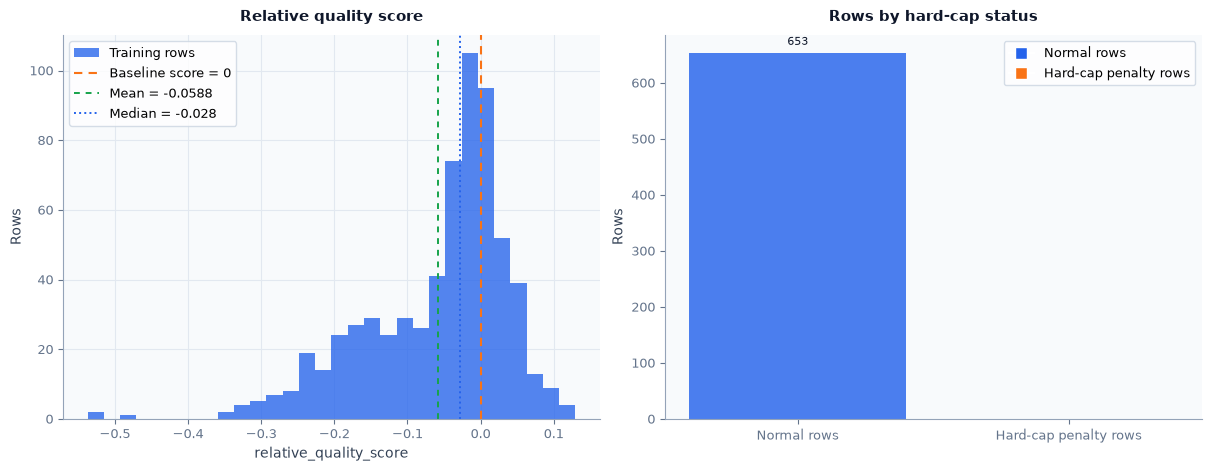

findfont: Failed to find font weight semibold, now using 700.


Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\02_descriptor_distributions.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\02_descriptor_distributions.svg


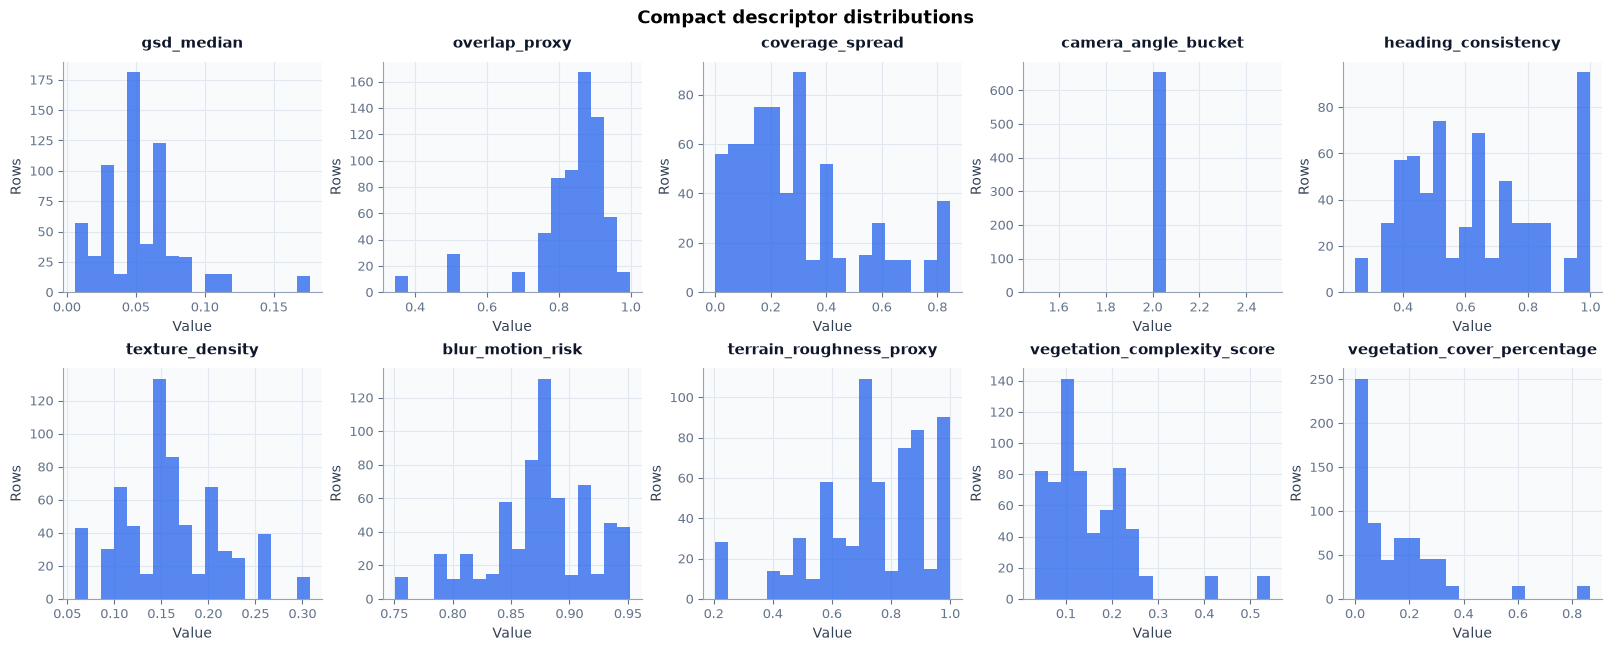

Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\03_training_multiplier_score_scatter.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\03_training_multiplier_score_scatter.svg


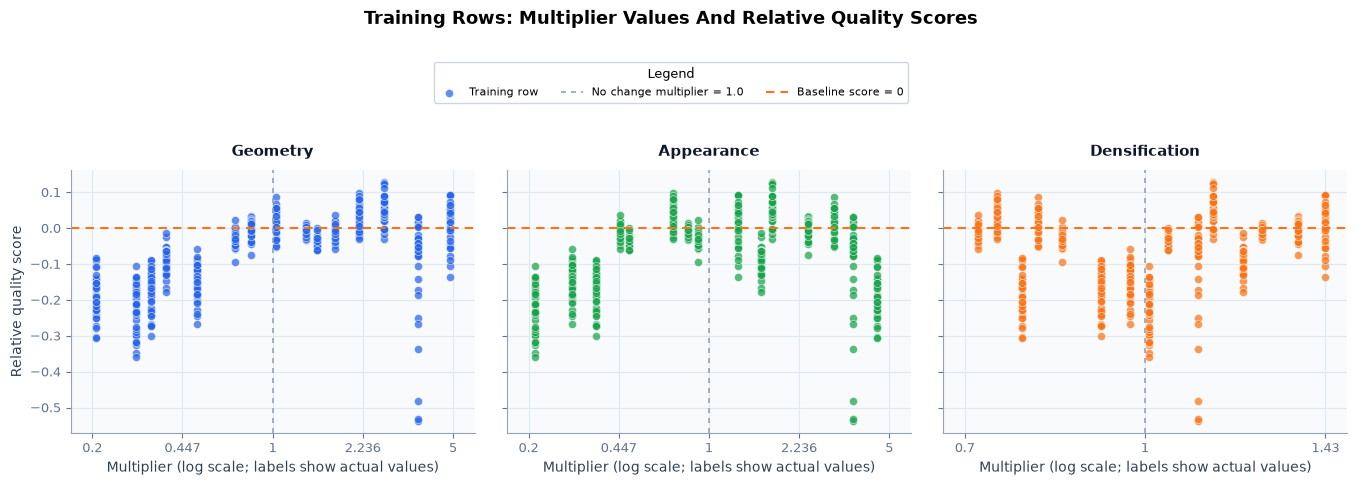

In [165]:
if not training_rows:
    print("No descriptors to visualize.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
    score_values = df_descriptors["score"].dropna()
    axes[0].hist(score_values, bins=30, color=CHART_COLORS["blue"], alpha=0.78, label="Training rows")
    style_chart_axis(axes[0], title="Relative quality score", xlabel=SCORE_KEY, ylabel="Rows")
    axes[0].axvline(0, color=CHART_COLORS["orange"], linestyle=(0, (4, 3)), linewidth=1.5, label="Baseline score = 0")
    if not score_values.empty:
        mean_score = float(score_values.mean())
        median_score = float(score_values.median())
        axes[0].axvline(mean_score, color=CHART_COLORS["green"], linestyle=(0, (3, 3)), linewidth=1.4, label=f"Mean = {compact_number(mean_score)}")
        axes[0].axvline(median_score, color=CHART_COLORS["blue"], linestyle=":", linewidth=1.4, label=f"Median = {compact_number(median_score)}")
    axes[0].legend(loc="best", fontsize=9)

    if "hard_cap_penalty_row" in df_descriptors:
        counts = df_descriptors["hard_cap_penalty_row"].map({False: "Normal rows", True: "Hard-cap penalty rows"}).value_counts().reindex(["Normal rows", "Hard-cap penalty rows"]).fillna(0)
        bars = axes[1].bar(counts.index, counts.values, color=[CHART_COLORS["blue"], CHART_COLORS["orange"]], alpha=0.82)
        annotate_bars(axes[1], bars, fmt_digits=0)
        style_chart_axis(axes[1], title="Rows by hard-cap status", xlabel="", ylabel="Rows", grid=False)
        axes[1].legend(
            handles=[
                plt.Line2D([0], [0], marker="s", color="w", label="Normal rows", markerfacecolor=CHART_COLORS["blue"], markersize=9),
                plt.Line2D([0], [0], marker="s", color="w", label="Hard-cap penalty rows", markerfacecolor=CHART_COLORS["orange"], markersize=9),
            ],
            loc="best",
            fontsize=9,
        )
    save_chart(fig, "01_score_and_hard_cap_rows")
    plt.show()

    numeric_cols = [key for key in COMPACT_FEATURE_KEYS if key != "intercept"]
    fig, axes = plt.subplots(2, 5, figsize=(16, 6.4), constrained_layout=True)
    axes = axes.ravel()
    for ax, col in zip(axes, numeric_cols):
        ax.hist(df_descriptors[col].dropna(), bins=18, color=CHART_COLORS["blue"], alpha=0.76, label="Rows")
        style_chart_axis(ax, title=col, xlabel="Value", ylabel="Rows")
    fig.suptitle("Compact descriptor distributions", fontsize=13, fontweight="semibold")
    save_chart(fig, "02_descriptor_distributions")
    plt.show()

    if not df_multipliers.empty:
        fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.7), sharey=True, gridspec_kw={"wspace": 0.08})
        for ax, group in zip(axes, COMPACT_MODEL_GROUP_KEYS):
            group_df = df_multipliers[df_multipliers["group"] == group].copy()
            if group_df.empty:
                set_multiplier_log_x_axis(ax, bounds=GROUP_BOUNDS.get(group))
                style_chart_axis(ax, title=GROUP_DISPLAY.get(group, group), xlabel="Multiplier (log scale)", ylabel="Relative quality score")
                continue

            normal_rows = group_df[~group_df["hard_cap_penalty_row"]]
            hard_cap_rows = group_df[group_df["hard_cap_penalty_row"]]
            if not normal_rows.empty:
                ax.scatter(
                    normal_rows["multiplier"],
                    normal_rows["score"],
                    s=34,
                    color=GROUP_COLORS.get(group, CHART_COLORS["blue"]),
                    edgecolor="white",
                    linewidth=0.45,
                    alpha=0.72,
                    label="Training row",
                )
            if not hard_cap_rows.empty:
                ax.scatter(
                    hard_cap_rows["multiplier"],
                    hard_cap_rows["score"],
                    s=44,
                    color=CHART_COLORS["orange"],
                    marker="x",
                    linewidth=1.2,
                    alpha=0.9,
                    label="Hard-cap penalty row",
                )


            set_multiplier_log_x_axis(ax, values=group_df["multiplier"].dropna().values, bounds=GROUP_BOUNDS.get(group))
            ax.axvline(1.0, color=CHART_COLORS["slate_axis"], linestyle=(0, (3, 3)), linewidth=1.2, label="No change multiplier = 1.0")
            add_score_zero_line(ax, label="Baseline score = 0")
            style_chart_axis(
                ax,
                title=GROUP_DISPLAY.get(group, group),
                xlabel="Multiplier (log scale; labels show actual values)",
                ylabel="Relative quality score" if ax is axes[0] else "",
            )
        handles, labels_for_legend = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels_for_legend,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=4,
            fontsize=8,
            title="Legend",
            title_fontsize=9,
            frameon=True,
            framealpha=0.95,
        )
        fig.suptitle("Training Rows: Multiplier Values And Relative Quality Scores", fontsize=13, fontweight="semibold", y=1.08)
        fig.subplots_adjust(top=0.74, left=0.065, right=0.99, bottom=0.18, wspace=0.08)
        save_chart(fig, "03_training_multiplier_score_scatter")
        plt.show()


## 6. Train Featurewise Ridge Quality Scoring

This is the main scoring-model training section.

Ridge Regression is a linear model with regularization. The linear part learns how descriptors and multiplier choices relate to the relative quality score. The regularization part keeps the learned weights from becoming too large, which helps reduce overfitting when the dataset is limited.

A **scaler** stores the mean and standard deviation of each descriptor. Scaling is needed because descriptors use different units and ranges. A **Ridge lambda** is the regularization strength. A larger lambda makes the model smoother and more conservative. **MSE**, or mean squared error, is the average squared difference between predicted scores and actual scores. Lower MSE means a closer fit to the prepared rows.


In [166]:
def empty_compact_ridge_model(lambda_ridge: float, scaler: dict[str, dict[str, float]], candidate_points: int, bounds: dict[str, tuple[float, float]]) -> dict[str, Any]:
    """Create the Ridge normal-equation state used by this notebook."""
    # The design vector combines descriptors, multiplier choices, squared multiplier terms, and descriptor-multiplier interactions.
    d_x = len(build_compact_vector({}, scaler))
    d_phi = d_x + len(COMPACT_MODEL_GROUP_KEYS) + len(COMPACT_MODEL_GROUP_KEYS) + (d_x - 1) * len(COMPACT_MODEL_GROUP_KEYS)
    return {
        "version": 1,
        "model_family": "compact_featurewise_ridge_regression",
        "mode": "exif_compact_featurewise",
        "lambda_ridge": float(lambda_ridge),
        "runs": 0,
        "score_mean": 0.0,
        "feature_scaler": scaler,
        "candidate_points": int(max(5, candidate_points)),
        "log_multiplier_bounds": {key: [float(bounds[key][0]), float(bounds[key][1])] for key in COMPACT_MODEL_GROUP_KEYS},
        "action_space": "joint_log_multiplier",
        "design": "x_plus_three_actions_plus_action2_plus_xa",
        # Ridge regularization starts as lambda times the identity matrix before rows are added.
        "A": (np.eye(d_phi, dtype=np.float64) * float(lambda_ridge)).tolist(),
        "b": np.zeros(d_phi, dtype=np.float64).tolist(),
        "n": 0,
        "design_dim": d_phi,
    }


def solve_theta(model: dict[str, Any]) -> np.ndarray:
    """Solve the Ridge linear system to get the learned scoring weights."""
    A = np.array(model.get("A", []), dtype=np.float64)
    b = np.array(model.get("b", []), dtype=np.float64)
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ b


def compute_compact_ridge_metrics(model: dict[str, Any], rows: list[dict[str, Any]], score_key: str, group_bounds: dict[str, Any] | None = None) -> dict[str, Any]:
    """Measure how closely the trained Ridge model fits the prepared rows."""
    bounds = normalise_compact_group_bounds(group_bounds or model.get("log_multiplier_bounds"))
    scaler = model.get("feature_scaler") if isinstance(model.get("feature_scaler"), dict) else {}
    theta = solve_theta(model)
    residuals = []
    targets = []
    for row in rows:
        features = row.get("x_features")
        score = row.get(score_key)
        selected = row.get("selected_multipliers")
        if not isinstance(features, dict) or not isinstance(selected, dict):
            continue
        action_logs = compact_action_logs_from_multipliers(selected, bounds=bounds)
        if action_logs is None or not isinstance(score, (int, float)):
            continue
        pred = float(build_compact_score_design_vector(build_compact_vector(features, scaler), action_logs) @ theta)
        target = float(score)
        if math.isfinite(target):
            residuals.append(pred - target)
            targets.append(target)
    if not residuals:
        return {"mse": float("inf"), "rmse": float("inf"), "mae": float("inf"), "r_squared": 0.0, "samples": 0, "avg_val_mse": float("inf")}
    arr = np.array(residuals, dtype=np.float64)
    target_arr = np.array(targets, dtype=np.float64)
    mse = float(np.mean(arr * arr))
    ss_tot = float(np.sum((target_arr - float(np.mean(target_arr))) ** 2))
    ss_res = float(np.sum(arr * arr))
    return {"mse": mse, "rmse": float(math.sqrt(mse)), "mae": float(np.mean(np.abs(arr))), "r_squared": 1.0 - (ss_res / ss_tot) if ss_tot > 1e-10 else 0.0, "samples": len(residuals), "avg_val_mse": mse}


def train_compact_featurewise_ridge_model(rows: list[dict[str, Any]], score_key: str, lambda_ridge: float, candidate_points: int, group_bounds: dict[str, Any] | None = None):
    """Train one Ridge scoring model for one lambda value."""
    bounds = normalise_compact_group_bounds(group_bounds)
    # Ridge is sensitive to feature scale, so descriptors are standardized before design vectors are built.
    scaler = build_compact_feature_scaler(rows)
    model = empty_compact_ridge_model(lambda_ridge, scaler, candidate_points, bounds)
    score_sum = 0.0
    runs = 0
    for row in rows:
        features = row.get("x_features")
        score = row.get(score_key)
        selected = row.get("selected_multipliers")
        if not isinstance(features, dict) or not isinstance(selected, dict):
            continue
        if not isinstance(score, (int, float)):
            continue
        score_f = float(score)
        if not math.isfinite(score_f):
            continue
        action_logs = compact_action_logs_from_multipliers(selected, bounds=bounds)
        if action_logs is None:
            continue
        phi = build_compact_score_design_vector(build_compact_vector(features, scaler), action_logs)
        # Each row adds its design-vector contribution to the normal equations.
        model["A"] = (np.array(model["A"], dtype=np.float64) + np.outer(phi, phi)).tolist()
        model["b"] = (np.array(model["b"], dtype=np.float64) + score_f * phi).tolist()
        model["n"] = int(model.get("n", 0)) + 1
        runs += 1
        score_sum += score_f
    model["runs"] = runs
    model["score_mean"] = score_sum / runs if runs else 0.0
    metrics = compute_compact_ridge_metrics(model, rows, score_key=score_key, group_bounds=bounds)
    return model, metrics, float(np.linalg.norm(solve_theta(model)))


ridge_results = []
if not training_rows:
    print("Skipping Ridge training because no rows were found.")
else:
    print("Compact Ridge training status")
    print("-----------------------------")
    print(f"Training rows          : {len(training_rows)}")
    print(f"Lambda candidates      : {RIDGE_LAMBDAS}")
    print(f"Candidate grid points  : {CANDIDATE_POINTS}")
    # The selected lambda is the one with the lowest average MSE for this dataset.
    for lam in tqdm(RIDGE_LAMBDAS, desc="Compact Ridge lambda search", unit="lambda"):
        model, metrics, theta_norm = train_compact_featurewise_ridge_model(training_rows, SCORE_KEY, lam, CANDIDATE_POINTS, group_bounds=GROUP_BOUNDS)
        ridge_results.append({"lambda": lam, "model": model, "metrics": metrics, "theta_norm": theta_norm})
        print(f"lambda={float(lam):g}  avg_val_mse={float(metrics['avg_val_mse']):.6f}  theta_norm={theta_norm:.6f}")
    best = min(ridge_results, key=lambda item: item["metrics"]["avg_val_mse"])
    compact_ridge_model = best["model"]
    compact_ridge_metrics = best["metrics"]
    model_path = OUT_DIR / "compact_featurewise_ridge_model.json"
    model_path.write_text(json.dumps({"schema": "compact_featurewise_ridge_regression_v1", "model": compact_ridge_model, "metrics": compact_ridge_metrics}, indent=2), encoding="utf-8")
    print("\nCompact Ridge training complete")
    print("-------------------------------")
    print("lambda is the tested regularization strength. avg_val_mse is the average validation mean squared error; lower is better. theta_norm is the size of the learned coefficient vector, which gives a rough sense of model complexity.")
    display(pd.DataFrame([{"lambda": r["lambda"], **r["metrics"], "theta_norm": r["theta_norm"]} for r in ridge_results]))
    print(f"Selected lambda: {best['lambda']}")
    print(f"Best metrics: {json.dumps(compact_ridge_metrics, indent=2)}")
    print(f"Saved model: {model_path}")


Compact Ridge training status
-----------------------------
Training rows          : 653
Lambda candidates      : [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
Candidate grid points  : 30


Compact Ridge lambda search:   0%|          | 0/7 [00:00<?, ?lambda/s]

lambda=0.1  avg_val_mse=0.002649  theta_norm=0.376360
lambda=0.5  avg_val_mse=0.002678  theta_norm=0.257266
lambda=1  avg_val_mse=0.002709  theta_norm=0.193731
lambda=2  avg_val_mse=0.002746  theta_norm=0.141456
lambda=5  avg_val_mse=0.002791  theta_norm=0.101222
lambda=10  avg_val_mse=0.002819  theta_norm=0.087340
lambda=20  avg_val_mse=0.002845  theta_norm=0.080030

Compact Ridge training complete
-------------------------------
lambda is the tested regularization strength. avg_val_mse is the average validation mean squared error; lower is better. theta_norm is the size of the learned coefficient vector, which gives a rough sense of model complexity.


,lambda,mse,rmse,mae,r_squared,samples,avg_val_mse,theta_norm
0,0.1,0.002649,0.051464,0.031786,0.724035,653,0.002649,0.376360
1,0.5,0.002678,0.051750,0.031962,0.720958,653,0.002678,0.257266
2,1.0,0.002709,0.052049,0.032222,0.717726,653,0.002709,0.193731
3,2.0,0.002746,0.052406,0.032562,0.713840,653,0.002746,0.141456
4,5.0,0.002791,0.052833,0.033040,0.709159,653,0.002791,0.101222
5,10.0,0.002819,0.053092,0.033309,0.706290,653,0.002819,0.087340
6,20.0,0.002845,0.053338,0.033561,0.703572,653,0.002845,0.080030


Selected lambda: 0.1
Best metrics: {
  "mse": 0.002648502104331235,
  "rmse": 0.051463599799579075,
  "mae": 0.0317859588586825,
  "r_squared": 0.7240351111536809,
  "samples": 653,
  "avg_val_mse": 0.002648502104331235
}
Saved model: D:\bimba3d-re\notebooks\_outputs\compact_featurewise_ridge_model.json


## 7. Visualize Lambda Search

This chart explains which lambda value was selected.

Each point shows the average MSE for one tested lambda. The selected point is the lambda with the lowest MSE. If several values are very close, the difference may not be meaningful; in that case, the smoother model is often easier to trust.


Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\04_lambda_search.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\04_lambda_search.svg


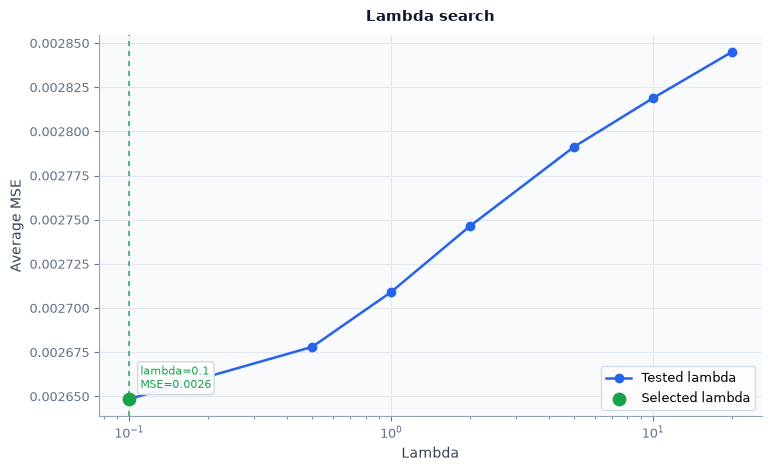

In [167]:
if not ridge_results:
    print("No metrics to visualize.")
else:
    df_ridge = pd.DataFrame([{"lambda": r["lambda"], **r["metrics"], "theta_norm": r["theta_norm"]} for r in ridge_results])
    best_row = df_ridge.loc[df_ridge["avg_val_mse"].idxmin()]
    fig, ax = plt.subplots(figsize=(7.6, 4.6), constrained_layout=True)
    ax.plot(df_ridge["lambda"], df_ridge["avg_val_mse"], marker="o", color=CHART_COLORS["blue"], linewidth=1.8, label="Tested lambda")
    ax.scatter([best_row["lambda"]], [best_row["avg_val_mse"]], color=CHART_COLORS["green"], s=80, zorder=5, label="Selected lambda")
    ax.axvline(best_row["lambda"], color=CHART_COLORS["green"], linestyle=(0, (3, 3)), linewidth=1.2, alpha=0.85)
    annotate_point(
        ax,
        float(best_row["lambda"]),
        float(best_row["avg_val_mse"]),
        f"lambda={compact_number(best_row['lambda'])}\nMSE={compact_number(best_row['avg_val_mse'])}",
        color=CHART_COLORS["green"],
    )
    ax.set_xscale("log")
    style_chart_axis(ax, title="Lambda search", xlabel="Lambda", ylabel="Average MSE")
    ax.legend(loc="best", fontsize=9)
    save_chart(fig, "04_lambda_search")
    plt.show()


## 8. Select Multipliers By Scoring Candidates

This section uses the trained scoring model to choose multipliers for preview projects.

A **candidate grid** is the list of possible multiplier combinations the notebook will score. The grid is built from the multiplier bounds stored in the training-data folder. The scoring model checks every joint candidate, selects the candidate with the highest predicted relative quality score, and then expands the three compact group multipliers into final Gaussian Splatting parameter values.

The candidate search is done in log space because multipliers are multiplicative. This gives a balanced search around `1.0`: for example, `0.5 -> 1.0` and `1.0 -> 2.0` are treated as similar-sized changes.


In [168]:
def candidate_logs_by_group(candidate_points: int, bounds: dict[str, tuple[float, float]], source: dict[str, Any] | None = None) -> dict[str, np.ndarray]:
    """Return candidate log multipliers for the joint search grid."""
    # The candidate search uses log space because multipliers are naturally multiplicative.
    # Equal spacing in log space treats 0.5 -> 1.0 similarly to 1.0 -> 2.0.
    out = {}
    for group in COMPACT_MODEL_GROUP_KEYS:
        lo, hi = bounds[group]
        raw = source.get(group) if isinstance(source, dict) else None
        if isinstance(raw, list) and raw:
            values = [clamp_float(float(value), math.log(lo), math.log(hi)) for value in raw if isinstance(value, (int, float))]
            out[group] = np.array(values or [0.0], dtype=np.float64)
        else:
            out[group] = np.linspace(math.log(lo), math.log(hi), int(max(5, candidate_points)), dtype=np.float64)
    return out


def candidate_checks_by_group(candidates_by_group: dict[str, np.ndarray], combos: list[tuple[float, ...]], scores: list[float], selected_logs: dict[str, float]) -> dict[str, list[dict[str, Any]]]:
    """Summarize each group's candidates for charting and debugging."""
    # The model scores full multiplier combinations. For a one-group chart, we keep
    # the best score found among combinations that include each candidate value.
    checks = {}
    for group_index, group in enumerate(COMPACT_MODEL_GROUP_KEYS):
        rows = []
        for candidate_log in candidates_by_group[group]:
            matching_scores = [scores[index] for index, combo in enumerate(combos) if abs(float(combo[group_index]) - float(candidate_log)) < 1e-12]
            score = float(max(matching_scores)) if matching_scores else 0.0
            rows.append({"candidate_log_multiplier": float(candidate_log), "candidate_multiplier": float(math.exp(float(candidate_log))), "predicted_score": score, "selected": bool(abs(float(candidate_log) - float(selected_logs[group])) < 1e-12)})
        checks[group] = rows
    return checks


def final_parameter_values(base_params: dict[str, float], multipliers: dict[str, float]) -> dict[str, float]:
    """Apply group multipliers to base training params so final values are visible."""
    return {
        "feature_lr": base_params["feature_lr"] * multipliers["feature_lr_mult"],
        "position_lr_init": base_params["position_lr_init"] * multipliers["position_lr_init_mult"],
        "scaling_lr": base_params["scaling_lr"] * multipliers["scaling_lr_mult"],
        "opacity_lr": base_params["opacity_lr"] * multipliers["opacity_lr_mult"],
        "rotation_lr": base_params["rotation_lr"] * multipliers["rotation_lr_mult"],
        "densify_grad_threshold": base_params["densify_grad_threshold"] * multipliers["densify_grad_threshold_mult"],
        "opacity_threshold": base_params["opacity_threshold"] * multipliers["opacity_threshold_mult"],
        "lambda_dssim": base_params["lambda_dssim"] * multipliers["lambda_dssim_mult"],
    }



def select_compact_ridge_from_model(model: dict[str, Any], x_features: dict[str, Any], candidate_log_multipliers_by_group: dict[str, Any] | None = None) -> dict[str, Any]:
    """Score all candidate combinations with the trained Ridge model and select the best one."""
    bounds = normalise_compact_group_bounds(model.get("log_multiplier_bounds"))
    candidates_by_group = candidate_logs_by_group(int(model.get("candidate_points", CANDIDATE_POINTS)), bounds, candidate_log_multipliers_by_group)
    combos = list(itertools.product(*(candidates_by_group[group] for group in COMPACT_MODEL_GROUP_KEYS)))
    x = build_compact_vector(x_features, model.get("feature_scaler") if isinstance(model.get("feature_scaler"), dict) else {})
    theta = solve_theta(model)
    scores = [float(build_compact_score_design_vector(x, np.array(combo, dtype=np.float64)) @ theta) for combo in combos]
    spread = float(max(scores) - min(scores)) if scores else 0.0
    # If all candidates receive almost the same score, the model has no clear preference.
    # In that case, use neutral log multipliers near zero.
    if spread < 1e-6 or not scores:
        selected_logs = np.zeros(len(COMPACT_MODEL_GROUP_KEYS), dtype=np.float64)
        selected_score = scores[len(scores) // 2] if scores else 0.0
        has_signal = False
    else:
        best_idx = int(np.argmax(scores))
        selected_logs = np.array(combos[best_idx], dtype=np.float64)
        selected_score = float(scores[best_idx])
        has_signal = True
    group_multipliers = {}
    group_log_multipliers = {}
    for index, group in enumerate(COMPACT_MODEL_GROUP_KEYS):
        lo, hi = bounds[group]
        mult = clamp_float(float(math.exp(float(selected_logs[index]))), lo, hi)
        group_multipliers[group] = mult
        group_log_multipliers[group] = float(math.log(max(mult, 1e-9)))
    selected_multipliers, selected_log_multipliers = expand_compact_group_multipliers(group_multipliers)
    return {
        "selected_preset": "compact_featurewise_ridge_regression",
        "yhat_scores": selected_multipliers,
        "selected_multipliers": selected_multipliers,
        "selected_multipliers_raw": dict(selected_multipliers),
        "selected_log_multipliers": selected_log_multipliers,
        "selected_log_multipliers_raw": dict(selected_log_multipliers),
        "group_multipliers": group_multipliers,
        "group_log_multipliers": group_log_multipliers,
        "selected_score": selected_score,
        "score_spreads": {group: spread for group in COMPACT_MODEL_GROUP_KEYS},
        "candidate_score_checks": candidate_checks_by_group(candidates_by_group, combos, scores, group_log_multipliers),
        "candidate_points": int(model.get("candidate_points") or 0),
        "has_signal": has_signal,
        "n_runs": int(model.get("runs") or model.get("n") or 0),
        "model_type": "compact_featurewise_ridge_regression",
    }


prediction_rows = []
if "compact_ridge_model" not in globals() or not test_projects:
    print("No trained compact Ridge model or no preview projects.")
else:
    for project in test_projects:
        result = select_compact_ridge_from_model(compact_ridge_model, project["features"])
        prediction_rows.append({**project, **result, "final_values": final_parameter_values(BASE_PARAMS, result["selected_multipliers"])})
    preview_path = OUT_DIR / "compact_ridge_prediction_preview.json"
    preview_path.write_text(json.dumps({"rows": prediction_rows}, indent=2), encoding="utf-8")
    print(f"Prediction rows: {len(prediction_rows)}")
    print(f"Saved preview: {preview_path}")


Prediction rows: 46
Saved preview: D:\bimba3d-re\notebooks\_outputs\compact_ridge_prediction_preview.json


## 9. Prediction Table

This table shows the selected result for each preview project.

For each project, it prints the three compact group multipliers and the final Gaussian Splatting parameter values produced from those multipliers. The final values are calculated from the saved base Gaussian Splatting parameters stored in the training-data folder.

Use this table to inspect the exact values before looking at the charts. A multiplier above `1.0` increases a parameter. A multiplier below `1.0` decreases it.


In [169]:
if not prediction_rows:
    print("No predictions to display.")
else:
    summary_rows = []
    for row in prediction_rows:
        summary = {"project": row["project_name"], "selected_score": row.get("selected_score")}
        summary.update({f"group_{key}": value for key, value in row["group_multipliers"].items()})
        summary.update({f"final_{key}": value for key, value in row["final_values"].items()})
        summary_rows.append(summary)
    df_predictions = pd.DataFrame(summary_rows)
    print("Prediction table")
    print("selected_score is the model-predicted relative quality score for the selected candidate. group_* columns are selected multipliers; final_* columns are the actual Gaussian Splatting training parameter values after applying those multipliers.")
    display(df_predictions)

    first_prediction = prediction_rows[0]
    candidate_rows = []
    for group in COMPACT_MODEL_GROUP_KEYS:
        checks = first_prediction.get("candidate_score_checks", {}).get(group, [])
        candidate_values = [float(item["candidate_multiplier"]) for item in checks if isinstance(item, dict) and isinstance(item.get("candidate_multiplier"), (int, float))]
        selected_values = [float(item["candidate_multiplier"]) for item in checks if isinstance(item, dict) and item.get("selected") and isinstance(item.get("candidate_multiplier"), (int, float))]
        candidate_rows.append({
            "project": first_prediction["project_name"],
            "group": GROUP_DISPLAY.get(group, group),
            "candidate_count": len(candidate_values),
            "selected_multiplier": selected_values[0] if selected_values else first_prediction.get("group_multipliers", {}).get(group),
            "candidate_multipliers": ", ".join(compact_number(value, 3) for value in candidate_values),
        })
    print("Candidate multiplier arrays for the first preview project")
    print("These are the exact multiplier values scored by the model for each group. The selected multiplier should be one of these values.")
    display(pd.DataFrame(candidate_rows))


Prediction table
selected_score is the model-predicted relative quality score for the selected candidate. group_* columns are selected multipliers; final_* columns are the actual Gaussian Splatting training parameter values after applying those multipliers.


,project,selected_score,group_geometry_lr_mult,group_appearance_lr_mult,group_densification_mult,final_feature_lr,final_position_lr_init,final_scaling_lr,final_opacity_lr,final_rotation_lr,final_densify_grad_threshold,final_opacity_threshold,final_lambda_dssim
0,1-Montreal-City-Hall,0.070676,2.568864,1.319812,0.70,0.003300,0.000411,0.012844,0.065991,0.002569,0.000140,0.00350,0.263962
1,10_Holy_Ghost_Ukrainian_Church,0.065478,1.841308,1.319812,0.70,0.003300,0.000295,0.009207,0.065991,0.001841,0.000140,0.00350,0.263962
2,11-St-George-Church,0.065024,1.841308,1.319812,0.70,0.003300,0.000295,0.009207,0.065991,0.001841,0.000140,0.00350,0.263962
3,13-Murugan-Temple,0.048052,1.474745,1.319812,0.70,0.003300,0.000236,0.007374,0.065991,0.001475,0.000140,0.00350,0.263962
4,14-Hindu-Mandir,0.047335,1.181156,1.057067,1.43,0.002643,0.000189,0.005906,0.052853,0.001181,0.000286,0.00715,0.211413
5,15-Congregation-Shaar-Hashomayim,0.038974,1.841308,1.057067,1.43,0.002643,0.000295,0.009207,0.052853,0.001841,0.000286,0.00715,0.211413
6,16-Mosque,0.060540,2.057460,1.319812,0.70,0.003300,0.000329,0.010287,0.065991,0.002057,0.000140,0.00350,0.263962
7,17-Shaughnessy-Mansion,0.070886,1.647865,1.319812,0.70,0.003300,0.000264,0.008239,0.065991,0.001648,0.000140,0.00350,0.263962
8,2-Resurrection-Chapel,0.056762,1.474745,1.319812,0.70,0.003300,0.000236,0.007374,0.065991,0.001475,0.000140,0.00350,0.263962
9,3-Maison_Louis-Hippolyte_Lafontaine,0.059029,1.647865,1.181156,0.70,0.002953,0.000264,0.008239,0.059058,0.001648,0.000140,0.00350,0.236231


Candidate multiplier arrays for the first preview project
These are the exact multiplier values scored by the model for each group. The selected multiplier should be one of these values.


,project,group,candidate_count,selected_multiplier,candidate_multipliers
0,1-Montreal-City-Hall,Geometry,30,2.568864,"0.2, 0.223, 0.25, 0.279, 0.312, 0.348, 0.389, ..."
1,1-Montreal-City-Hall,Appearance,30,1.319812,"0.2, 0.223, 0.25, 0.279, 0.312, 0.348, 0.389, ..."
2,1-Montreal-City-Hall,Densification,30,0.700000,"0.7, 0.717, 0.735, 0.754, 0.772, 0.792, 0.811,..."


## 10. Visualize Selected Multipliers

This chart compares the selected compact multiplier groups across preview projects.

The horizontal line at `1.0` means no change from the base parameter value. Values above the line increase that group. Values below the line reduce it. The labels on the bars show the selected values directly, so the chart can be read without returning to the table.

The y-axis is log-spaced because multiplier steps are multiplicative, but the tick labels remain the actual multiplier values.


Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\05_selected_multiplier_groups.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\05_selected_multiplier_groups.svg


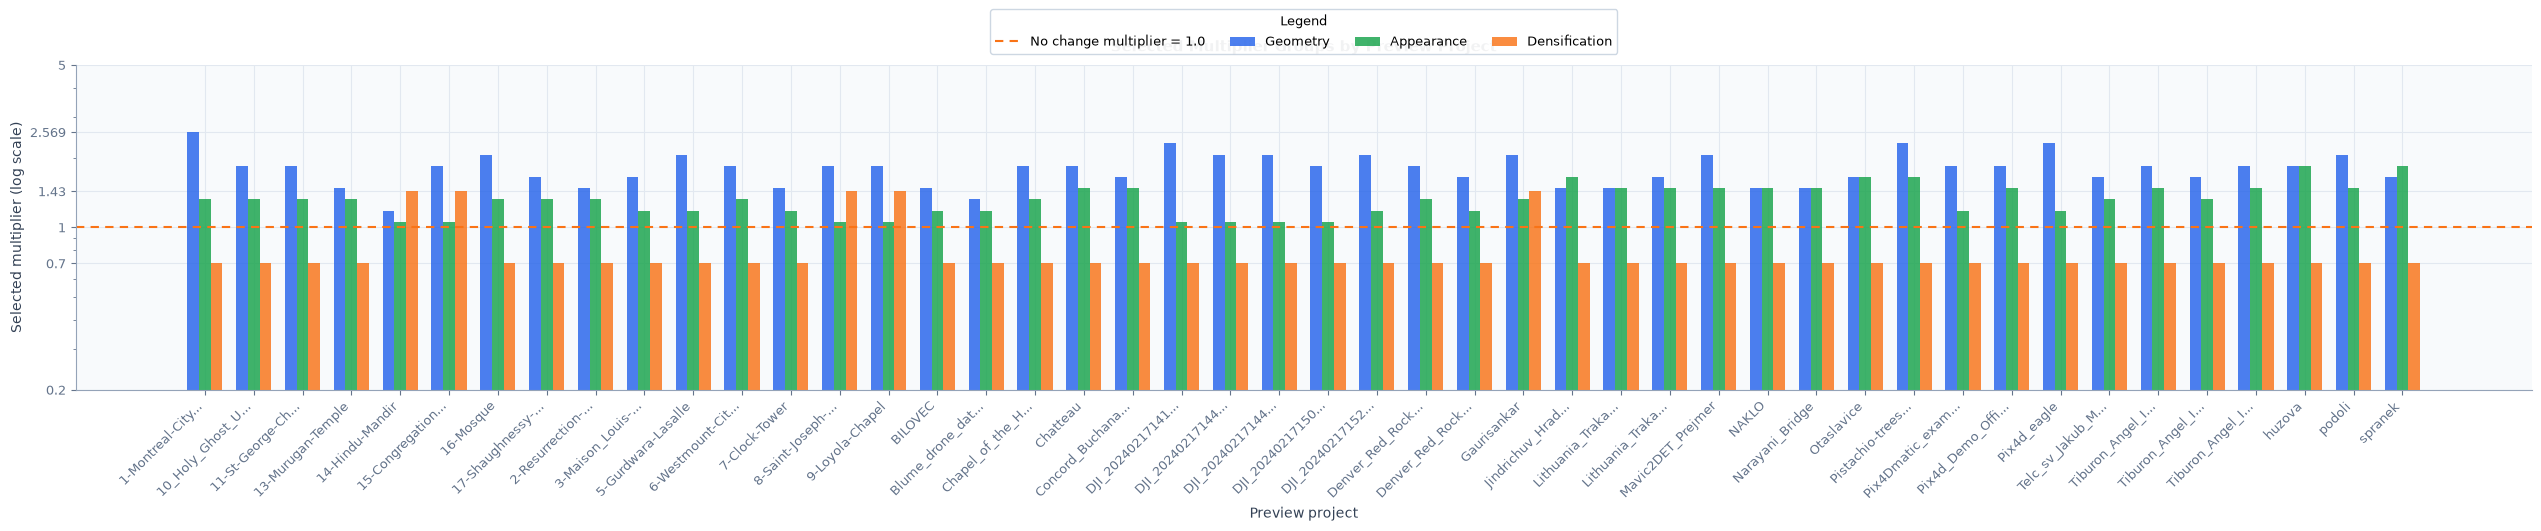

In [170]:
if not prediction_rows:
    print("No predictions to visualize.")
else:
    labels = [row["project_name"] for row in prediction_rows]
    x = np.arange(len(labels))
    width = 0.24
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.55), 5.2), constrained_layout=True)
    for offset, group in zip([-width, 0, width], COMPACT_MODEL_GROUP_KEYS):
        bars = ax.bar(
            x + offset,
            [row["group_multipliers"][group] for row in prediction_rows],
            width,
            label=GROUP_DISPLAY.get(group, group),
            color=GROUP_COLORS.get(group, CHART_COLORS["blue"]),
            alpha=0.82,
        )
        if len(labels) <= 12:
            annotate_bars(ax, bars, fmt_digits=3)
    selected_multiplier_values = [row["group_multipliers"][group] for row in prediction_rows for group in COMPACT_MODEL_GROUP_KEYS]
    set_multiplier_log_y_axis(ax, values=selected_multiplier_values)
    add_multiplier_reference_line(ax, label="No change multiplier = 1.0")
    ax.set_xticks(x)
    ax.set_xticklabels([short_label(label, 18) for label in labels], rotation=45, ha="right", fontsize=8)
    style_chart_axis(ax, title="Selected Multiplier Groups by Preview Project", xlabel="Preview project", ylabel="Selected multiplier (log scale)")
    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        fontsize=9,
        title="Legend",
        title_fontsize=9,
        frameon=True,
        framealpha=0.95,
        borderaxespad=0.4,
    )
    save_chart(fig, "05_selected_multiplier_groups")
    plt.show()


## 11. Candidate Multiplier Curves

This section shows how the model scored candidate values for one preview project and saves the same chart for every preview project.

Each panel focuses on one compact group. The x-axis is log-scaled, but the tick labels show the actual multiplier values. The highlighted point marks the selected multiplier and predicted score for that group.

The curve is a one-group view of a joint search. For each candidate value in one group, the chart shows the best score found among full multiplier combinations that included that value.


Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_1-Montreal-City-Hall.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_1-Montreal-City-Hall.svg


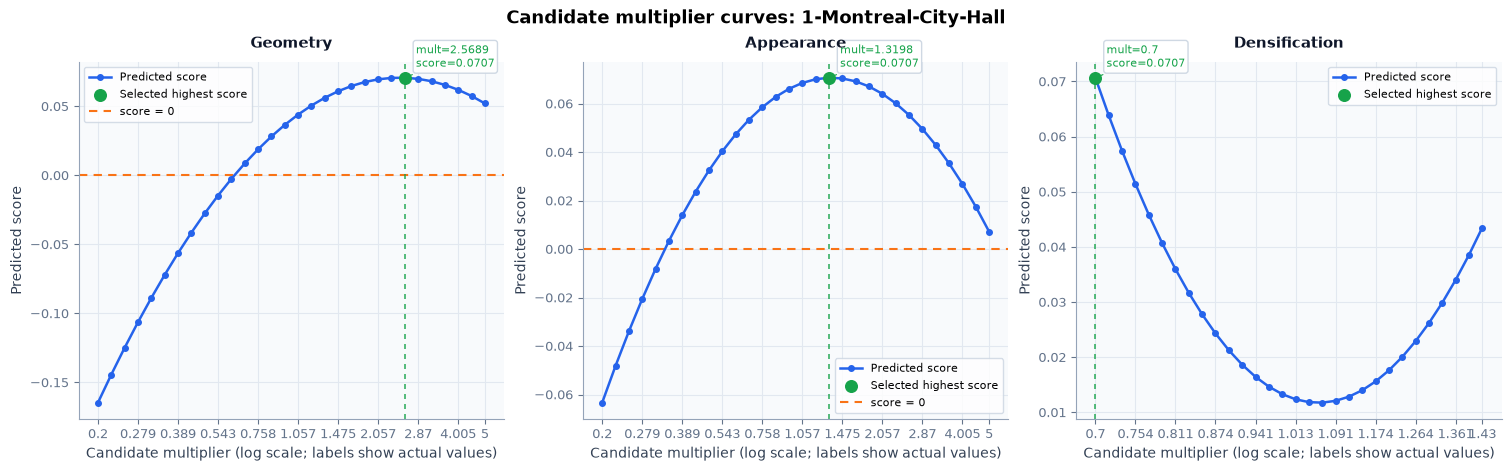

Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_10_Holy_Ghost_Ukrainian_Church.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_10_Holy_Ghost_Ukrainian_Church.svg
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_11-St-George-Church.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_11-St-George-Church.svg
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_13-Murugan-Temple.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_13-Murugan-Temple.svg
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_14-Hindu-Mandir.png
Saved chart: D:\bimba3d-re\notebooks\_outputs\charts\compact_ridge\candidate_curves\candidate_curves_14-Hindu-M

In [171]:
PROJECT_NAME = prediction_rows[0]["project_name"] if prediction_rows else None
if not prediction_rows:
    print("No prediction rows available.")
else:
    selected_row = next((row for row in prediction_rows if row["project_name"] == PROJECT_NAME), prediction_rows[0])
    candidate_dir = CHART_DIR / "candidate_curves"

    for row in prediction_rows:
        # Show one example in the notebook and save charts for every preview row for later inspection.
        plot_candidate_curve_set(
            row,
            save_name=f"candidate_curves_{row['project_name']}",
            directory=candidate_dir,
            show=(row is selected_row),
            save=True,
        )
    print(f"Saved candidate curve charts for {len(prediction_rows)} prediction rows in {candidate_dir}")


## 12. Using The Scoring Model For GS Testing

The prediction table shows the multiplier combination that the scoring model expects to work best for each preview project. These values are useful for inspection, comparison, and reporting, but they are not a replacement for a real Gaussian Splatting reconstruction test.

To run a real Gaussian Splatting test, upload the trained scoring-model artifact to the application and then select it in a testing pipeline. For this Ridge notebook, upload the saved `compact_featurewise_ridge_model.json` file from the output folder. This JSON contains the learned Ridge scoring model, descriptor scaler, multiplier bounds, candidate count, and fit metrics needed by the testing workflow.

In [Bimba3D-re](https://github.com/geomatupen/bimba3d_re), open **Train Models**, click **Upload Model**, choose **Featurewise Ridge Quality Model**, select the same Training Data source that was used by this notebook, and upload the Ridge model JSON. After upload, the model is registered in the model list and can be selected in a testing pipeline configuration. The testing pipeline then extracts descriptors for each test project, predicts multipliers with the uploaded scoring model, runs Gaussian Splatting training with those multipliers, and records the real quality results.

The JSON preview saved by this notebook is mainly for review and reproducibility. It helps you inspect predicted multipliers and chart values, but the application testing workflow uses the uploaded trained scoring-model artifact, not the preview JSON table.


## 13. Final Notebook Summary

The final cell gathers the main facts from the run in one place.

It prints the training-data folder, the saved settings read from that folder, the saved model or output files, the chart directory, and the first preview prediction. This is useful when comparing multiple runs, because it keeps the data source, model settings, and selected multipliers together.


In [172]:
summary = {
    "training_data_id": manifest.get("training_data_id"),
    "training_rows": len(training_rows),
    "score_key": build_summary.get("score_key", SCORE_KEY),
    "bounds_source": GROUP_BOUNDS_SOURCE,
    "bounds": GROUP_BOUNDS,
    "selected_lambda": best["lambda"] if ridge_results else None,
    "training_samples_in_model": compact_ridge_model.get("runs") if ridge_results else None,
    "model_path": str(model_path) if "model_path" in globals() else None,
}
print("Compact Ridge notebook summary")
print("------------------------------")
display(pd.DataFrame([summary]))

if prediction_rows:
    print("First preview prediction")
    first = prediction_rows[0]
    display(pd.DataFrame([{
        "project": first["project_name"],
        "selected_score": first.get("selected_score"),
        **first["group_multipliers"],
    }]))
    print("Final parameter values for first preview prediction")
    display(pd.DataFrame([first["final_values"]]).T.rename(columns={0: "value"}))


Compact Ridge notebook summary
------------------------------


,training_data_id,training_rows,score_key,bounds_source,bounds,selected_lambda,training_samples_in_model,model_path
0,training_data_20260710_183008_final_offline_da...,653,relative_quality_score,source_pipeline.fixed_log_space_bounds_snapshot,"{'geometry_lr_mult': (0.2, 5.0), 'appearance_l...",0.1,653,D:\bimba3d-re\notebooks\_outputs\compact_featu...


First preview prediction


,project,selected_score,geometry_lr_mult,appearance_lr_mult,densification_mult
0,1-Montreal-City-Hall,0.070676,2.568864,1.319812,0.7


Final parameter values for first preview prediction


,value
feature_lr,0.003300
position_lr_init,0.000411
scaling_lr,0.012844
opacity_lr,0.065991
rotation_lr,0.002569
densify_grad_threshold,0.000140
opacity_threshold,0.003500
lambda_dssim,0.263962
